# Video timing failure modes

Every way we have seen behavior-video timestamps go wrong in real data, one
example session each: what is wrong, and, where `video_timing_qc` corrects
it, how.

**The data.** Each camera has a CSV with one row per saved video frame (row
*i* is frame *i* of the video) and three columns:

- **Harp time**: seconds on the behavior clock (same clock as NWB events,
  FIP and spikes). This is the column analyses use.
- **Frame number**: the camera's exposure counter; +1 per exposure, including
  exposures that were never saved.
- **Camera time**: the camera's own clock per exposure.

The Harp board triggers every exposure (500 Hz, 2 ms apart) and logs each
trigger in `behavior/raw.harp/BehaviorEvents/Event_94.bin`, the **trigger
log**. The Bonsai workflow fills the Harp column by pairing the *n*-th frame
to arrive with the *n*-th trigger, so the Harp column is always the first
*N* triggers in order, whether or not every exposure arrived.

**The QC.** `check_video_timing` asks one question per check;
`timing_verdict` turns the answers into `use` or `exclude: <check>`, and
`correct_video_timing` corrects the cameras it can use. Each section prints
the checks that failed and the verdict.

| # | Failure mode | Example | Verdict | Cameras in the FIP screen |
|---|---|---|---|---|
| 1 | Harp glitch: one Harp value ~983 ms early | `809491_2025-10-02` | use (glitch fixed) | 52 (+6 with drops) |
| 2 | Frame drops: Harp times shift onto the wrong rows | `816212_2025-12-05` | use (re-indexed) | 86 |
| 3 | Frame drops and a Harp glitch | `816214_2025-12-02` | use (glitch fixed, then re-indexed) | 6 |
| 4 | Corrupted camera metadata | `816883_2025-12-04`, `763590_2025-05-02` | use (Harp as written) | 8 (2 also have a clock step) |
| 5 | Harp clock step | `800886_2025-08-26`, `751181_2025-02-26` | exclude: `harp_evenly_spaced` | 56 |
| 6 | More triggers than exposures | `818586_2026-01-16`, `818580_2025-11-25` | exclude: `trigger_log_count` | 8 |
| 7 | Camera not following the trigger | `816212_2025-12-24` | exclude: `clock_rates_agree` | 1 |

Counts are from the screen of the 301 curated FIP sessions (602 cameras,
`video_screen.csv`, 2026-10-02); 392 cameras had none of these. Examples are
bottom cameras. `763590` and `751181` are older LP sessions, not in that
screen. Files are downloaded from `s3://aind-open-data` over HTTPS (~150 MB
per session) into `VTQ_CACHE` (default `./video_timing_qc_data`).

In [1]:
import os
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aind_dynamic_foraging_behavior_video_analysis import video_timing_qc as vtq

S3 = "https://aind-open-data.s3.amazonaws.com"
CACHE = Path(os.environ.get("VTQ_CACHE", "video_timing_qc_data"))
LOG = "behavior/raw.harp/BehaviorEvents/Event_94.bin"

# One colour per role, in every figure.
AS_WRITTEN = "#eb6834"  # Harp column as written
CORRECTED = "#2a78d6"   # after correct_video_timing
TRIGGERS = "#1baf7a"    # trigger log
CAMERA = "0.45"         # camera clock
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "0.9",
    "lines.linewidth": 2,
})


def fetch(key):
    """Return a local copy of an aind-open-data object, downloading once."""
    path = CACHE / key
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print("downloading", key)
        urllib.request.urlretrieve(f"{S3}/{key}", path)
    return path


def load(session, csv="bottom_camera.csv"):
    """The camera's timing table and the session's trigger log."""
    timing = vtq.load_video_timing(fetch(f"{session}/behavior-videos/{csv}"))
    log = vtq.read_harp_trigger_log(fetch(f"{session}/{LOG}"))
    return timing, log


def report(timing, log):
    """Run every check; print the failed ones and the verdict."""
    checks = vtq.check_video_timing(timing, log)
    for _, row in checks[checks["passed"].eq(False)].iterrows():
        print(f"✗ {row['check']}: {row['message']}")
    print("verdict:", vtq.timing_verdict(checks))
    return checks


def check_rows(checks, check):
    """The rows a check flagged (first 100)."""
    return checks.set_index("check").loc[check, "rows"]


def rows_table(timing, rows, **extra):
    """One line per row: frame-number step, Harp time since the first row,
    and the step into the row of Harp and camera time. ``extra``: more
    columns, as full-length arrays."""
    rows = np.asarray(rows)
    harp = timing["harp_time_raw"].to_numpy()
    frames = timing["frame_number"].to_numpy()
    camera = timing["camera_time"].to_numpy()
    table = pd.DataFrame({
        "frame step": frames[rows] - frames[rows - 1],
        "Harp (s)": harp[rows] - harp[0],
        "Harp step (ms)": (harp[rows] - harp[rows - 1]) * 1e3,
        "camera step (ms)": (camera[rows] - camera[rows - 1]) * 1e3,
    }, index=pd.Index(rows, name="row"))
    for name, values in extra.items():
        table[name] = np.asarray(values)[rows]
    return table


def show(table):
    """Times in s to the µs, everything in ms to the µs."""
    formats = {}
    for column in table.columns:
        if "(s)" in column:
            formats[column] = "{:.6f}"
        elif "(ms)" in column:
            formats[column] = "{:.3f}"
    return table.style.format(formats)

## 1. Harp glitch

One Harp value is ~983 ms early. Frame numbers are continuous, the camera
steps 2 ms as usual, and the same row is bad in both cameras and in the
trigger log itself, so the bad value comes from the Harp board, not from
the pairing. Some sessions have smaller blips (2–6 ms) of the same kind.

`harp_has_no_glitches` finds a value that is off from the midpoint of its
two neighbours while those neighbours are two frames apart.

In [2]:
timing, log = load("behavior_809491_2025-10-02_09-23-46")
checks = report(timing, log)
r = check_rows(checks, "harp_has_no_glitches")[0]
show(rows_table(
    timing, np.arange(r - 3, r + 4),
    **{"trigger log step (ms)": np.diff(log, prepend=np.nan) * 1e3},
))

✗ harp_has_no_glitches: isolated glitches: 1
verdict: use


,frame step,Harp (s),Harp step (ms),camera step (ms),trigger log step (ms)
row,,,,,
183621,1,367.239584,1.984,1.999,1.984
183622,1,367.241600,2.016,2.000,2.016
183623,1,367.243584,1.984,2.003,1.984
183624,1,366.262560,-981.024,1.999,-981.024
183625,1,367.247584,985.024,1.999,985.024
183626,1,367.249600,2.016,2.000,2.016
183627,1,367.251584,1.984,1.999,1.984


Row 183624's Harp step is −981 ms, and the step out of it +985 ms, while
the camera steps 2 ms. The trigger log steps the same way: the log is wrong
here too.

**Correction.** The glitch row is replaced with the midpoint of its
neighbours (`harp_source` = `glitch_interpolated`); every other row keeps
its Harp time.

harp_source
original               2566315
glitch_interpolated          1 



,frame step,Harp (s),Harp step (ms),camera step (ms),corrected (s),corrected step (ms),source
row,,,,,,,
183622,1,367.241600,2.016,2.000,367.241600,2.016,original
183623,1,367.243584,1.984,2.003,367.243584,1.984,original
183624,1,366.262560,-981.024,1.999,367.245584,2.000,glitch_interpolated
183625,1,367.247584,985.024,1.999,367.247584,2.000,original
183626,1,367.249600,2.016,2.000,367.249600,2.016,original


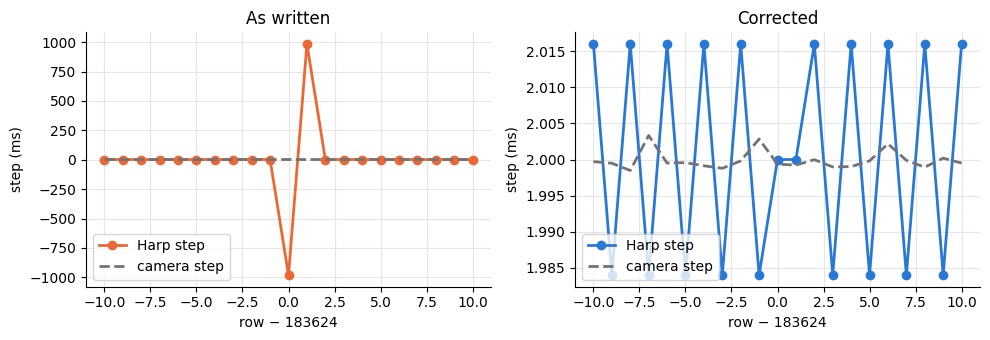

In [3]:
fixed = vtq.correct_video_timing(timing)
print(fixed["harp_source"].value_counts().to_string(), "\n")

window = np.arange(r - 10, r + 11)
camera_step = timing["camera_time"].diff().to_numpy()[window] * 1e3
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, harp, colour, title in [
    (axes[0], timing["harp_time_raw"], AS_WRITTEN, "As written"),
    (axes[1], fixed["harp_time"], CORRECTED, "Corrected"),
]:
    ax.plot(window - r, harp.diff().to_numpy()[window] * 1e3, "o-",
            color=colour, label="Harp step")
    ax.plot(window - r, camera_step, "--", color=CAMERA, label="camera step")
    ax.set(title=title, xlabel=f"row − {r}", ylabel="step (ms)")
    ax.legend(loc="lower left")
fig.tight_layout()

show(rows_table(
    timing, np.arange(r - 2, r + 3),
    **{"corrected (s)": fixed["harp_time"] - timing["harp_time_raw"].iloc[0],
       "corrected step (ms)": fixed["harp_time"].diff() * 1e3,
       "source": fixed["harp_source"]},
))

## 2. Frame drops

The camera exposes and numbers every frame, but the computer loses some of
them before they are saved. The Bonsai workflow pairs the *n*-th frame **to
arrive** with the *n*-th trigger, so after one lost frame every later row
carries the trigger time of the frame before it; each further loss shifts
it one more frame. The error never resets.

Here 187,024 single frames are lost, about one every 7–11 frames from the
first seconds on. Every Harp value is a real trigger time, on the wrong row.

The trigger log tells us the truth: a row's exposure is trigger number
`frame_number − first frame_number`, so its true time is
`log[frame_number − first]`.

In [4]:
timing, log = load("behavior_816212_2025-12-05_13-47-41")
checks = report(timing, log)

frames = timing["frame_number"].to_numpy()
harp = timing["harp_time_raw"].to_numpy()
exposure_time = log[frames - frames[0]]  # true time of each row
error = harp - exposure_time
print(f"\nrows {len(timing):,}, exposures {frames[-1] - frames[0] + 1:,}, "
      f"triggers in the log {len(log):,}")
print(f"Harp error on the last row: {error[-1]:.1f} s")

g = check_rows(checks, "no_frames_lost")[0]  # first row after a lost frame
show(rows_table(
    timing, np.arange(g - 2, g + 13),
    **{"exposure's trigger (s)": exposure_time - harp[0],
       "Harp error (ms)": error * 1e3},
))

✗ no_frames_lost: frames lost: 187024
verdict: use

rows 2,748,281, exposures 2,935,305, triggers in the log 2,935,305
Harp error on the last row: -374.0 s


,frame step,Harp (s),Harp step (ms),camera step (ms),exposure's trigger (s),Harp error (ms)
row,,,,,,
2230,1,4.459936,2.016,1.999,4.459936,0.000
2231,1,4.461920,1.984,1.999,4.461920,0.000
2232,2,4.463936,2.016,4.002,4.465920,-1.984
2233,1,4.465920,1.984,2.000,4.467936,-2.016
2234,1,4.467936,2.016,1.999,4.469920,-1.984
2235,1,4.469920,1.984,1.999,4.471936,-2.016
2236,1,4.471936,2.016,2.000,4.473920,-1.984
2237,1,4.473920,1.984,1.999,4.475936,-2.016
2238,1,4.475936,2.016,1.999,4.477920,-1.984


At each frame step of 2 (a lost frame), the Harp step stays 2 ms while the
camera steps 4 ms, so the Harp error grows by one frame interval (−2 ms)
and keeps it. Over the session it adds up to minutes:

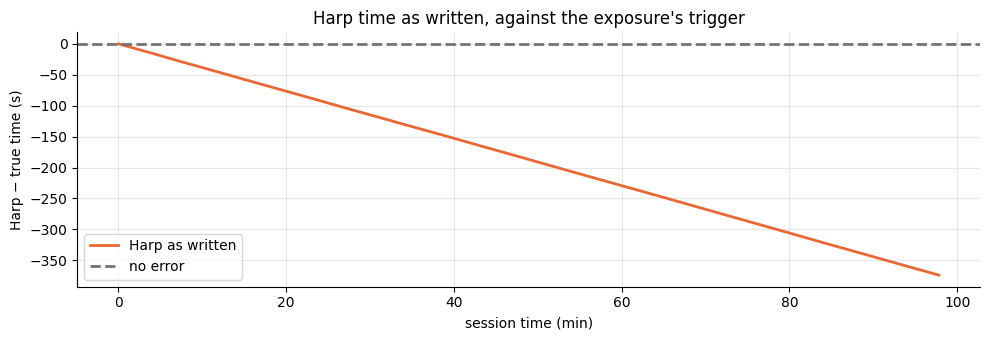

In [5]:
every = slice(None, None, 500)
minutes = (exposure_time - exposure_time[0]) / 60
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(minutes[every], error[every], color=AS_WRITTEN, label="Harp as written")
ax.axhline(0, color=CAMERA, linestyle="--", label="no error")
ax.set(xlabel="session time (min)", ylabel="Harp − true time (s)",
       title="Harp time as written, against the exposure's trigger")
ax.legend()
fig.tight_layout()

The Harp column also stops short: the last 187,024 triggers are never
paired with a row, so the column ends ~6 min before the camera does.

**Correction (re-index).** Each Harp value is moved to the row of its own
exposure (`reindexed`): the Harp column holds triggers 0 … *N*−1 and the
frame numbers say which trigger exposed each row. Rows whose trigger lies
past the end of the Harp column are estimated from camera time with a
linear fit over the last 10 min of re-indexed rows (`estimated_camera_fit`).
With the trigger log, those rows are read from the log instead. Then each
corrected Harp step must match the camera step (`harp_matches_camera`).

In [6]:
fixed = vtq.correct_video_timing(timing)  # from the CSV alone
from_log = vtq.correct_video_timing(timing, trigger_times=log)
print(fixed["harp_source"].value_counts().to_string(), "\n")

corrected_error = fixed["harp_time"].to_numpy() - exposure_time
tail = (fixed["harp_source"] == "estimated_camera_fit").to_numpy()
print(f"re-indexed rows: max |error| {np.abs(corrected_error[~tail]).max() * 1e6:.1f} µs")
print(f"estimated rows:  max |error| {np.abs(corrected_error[tail]).max() * 1e3:.3f} ms")
print(f"from the log:    max |error| "
      f"{np.abs(from_log['harp_time'].to_numpy() - exposure_time).max() * 1e6:.1f} µs")

show(rows_table(
    timing, np.arange(g - 2, g + 13),
    **{"exposure's trigger (s)": exposure_time - harp[0],
       "corrected (s)": fixed["harp_time"] - harp[0],
       "corrected step (ms)": fixed["harp_time"].diff() * 1e3,
       "source": fixed["harp_source"]},
))

harp_source
reindexed               2570888
estimated_camera_fit     175161
original                   2232 

re-indexed rows: max |error| 0.0 µs
estimated rows:  max |error| 0.062 ms
from the log:    max |error| 0.0 µs


,frame step,Harp (s),Harp step (ms),camera step (ms),exposure's trigger (s),corrected (s),corrected step (ms),source
row,,,,,,,,
2230,1,4.459936,2.016,1.999,4.459936,4.459936,2.016,original
2231,1,4.461920,1.984,1.999,4.461920,4.461920,1.984,original
2232,2,4.463936,2.016,4.002,4.465920,4.465920,4.000,reindexed
2233,1,4.465920,1.984,2.000,4.467936,4.467936,2.016,reindexed
2234,1,4.467936,2.016,1.999,4.469920,4.469920,1.984,reindexed
2235,1,4.469920,1.984,1.999,4.471936,4.471936,2.016,reindexed
2236,1,4.471936,2.016,2.000,4.473920,4.473920,1.984,reindexed
2237,1,4.473920,1.984,1.999,4.475936,4.475936,2.016,reindexed
2238,1,4.475936,2.016,1.999,4.477920,4.477920,1.984,reindexed


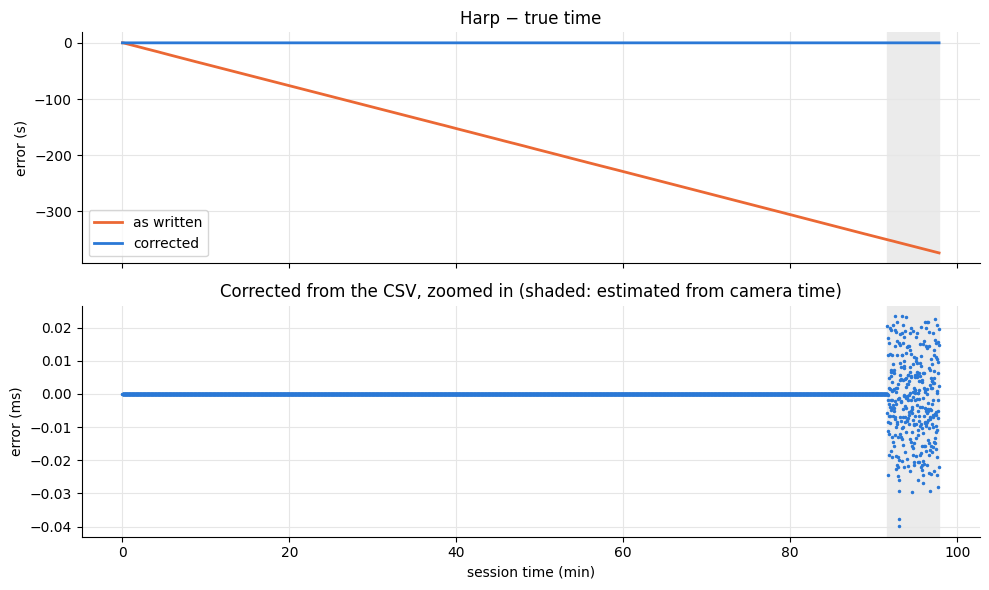

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(minutes[every], error[every], color=AS_WRITTEN, label="as written")
axes[0].plot(minutes[every], corrected_error[every], color=CORRECTED,
             label="corrected")
axes[0].set(ylabel="error (s)", title="Harp − true time")
axes[0].legend()
axes[1].plot(minutes[every], corrected_error[every] * 1e3, ".",
             color=CORRECTED, markersize=3)
axes[1].set(xlabel="session time (min)", ylabel="error (ms)",
            title="Corrected from the CSV, zoomed in "
                  "(shaded: estimated from camera time)")
for ax in axes:
    ax.axvspan(minutes[tail][0], minutes[-1], color="0.92", zorder=0)
fig.tight_layout()

## 3. Frame drops and a Harp glitch

Both failures in one camera: 172,631 lost frames and two ~983 ms glitches.
The glitches are in the trigger log (triggers 554395 and 1357400), and
since the Harp column holds the triggers in order, they sit on those same
rows of the CSV in both cameras.

In [8]:
timing, log = load("behavior_816214_2025-12-02_08-28-39")
checks = report(timing, log)
glitches = check_rows(checks, "harp_has_no_glitches")
print("glitch rows:", glitches)
show(rows_table(
    timing, np.concatenate([np.arange(g - 1, g + 2) for g in glitches]),
))

✗ no_frames_lost: frames lost: 172631
✗ harp_has_no_glitches: isolated glitches: 2
verdict: use
glitch rows: [554395, 1357400]


,frame step,Harp (s),Harp step (ms),camera step (ms)
row,,,,
554394,1,1108.781632,2.016,2.002
554395,1,1107.800576,-981.056,2.000
554396,1,1108.785632,985.056,1.999
1357399,1,2714.781600,1.984,1.999
1357400,1,2713.800576,-981.024,2.000
1357401,1,2714.785600,985.024,2.003


The glitch rule looks only at the Harp column (where row = trigger, even
with drops), so lost frames do not hide a glitch.

**Correction.** Glitches are fixed first, on the Harp column (trigger
order), then the values are re-indexed. The fixed triggers land on the
rows that saved their exposures. Skipping the glitch fix carries the bad
values into the re-indexed times, and the post-check
(`harp_matches_camera`) would exclude the camera:

In [9]:
frames = timing["frame_number"].to_numpy()
camera = timing["camera_time"].to_numpy()
fixed = vtq.correct_video_timing(timing)
print(fixed["harp_source"].value_counts().to_string(), "\n")

without_fix = vtq.estimate_missing_from_camera(
    vtq.reindex_to_exposures(frames, timing["harp_time_raw"].to_numpy()), camera
)
print("glitches fixed first:",
      vtq.check_harp_matches_camera(fixed["harp_time"], camera)["message"])
print("glitches not fixed:  ",
      vtq.check_harp_matches_camera(without_fix, camera)["message"], "\n")

landed = np.flatnonzero(fixed["harp_source"] == "glitch_interpolated")
show(rows_table(
    timing, np.concatenate([np.arange(g - 1, g + 2) for g in landed]),
    **{"trigger": frames - frames[0],
       "corrected step (ms)": fixed["harp_time"].diff() * 1e3,
       "source": fixed["harp_source"]},
))

harp_source
reindexed               2328973
estimated_camera_fit     161410
original                   2546
glitch_interpolated           2 

glitches fixed first: steps differing from camera by > 0.5 frame: 0
glitches not fixed:   steps differing from camera by > 0.5 frame: 4 



,frame step,Harp (s),Harp step (ms),camera step (ms),trigger,corrected step (ms),source
row,,,,,,,
518751,1,1037.496032,1.984,1.999,554394,2.016,reindexed
518752,1,1037.498048,2.016,2.000,554395,2.000,glitch_interpolated
518753,1,1037.500032,1.984,2.003,554396,2.000,reindexed
1269768,2,2539.520704,2.016,3.998,1357399,4.000,reindexed
1269769,1,2539.522688,1.984,2.003,1357400,2.000,glitch_interpolated
1269770,1,2539.524704,2.016,2.000,1357401,2.000,reindexed


After re-indexing, the fixed glitch triggers sit on the rows that saved
those exposures (rows 518752 and 1269769 here, not 554395 and 1357400). If
a glitch trigger's own exposure was lost, no row needs it: this happens on
the side camera of this session for trigger 554395.

## 4. Corrupted camera metadata

The frame number and camera time jump forward together by 1,049 frames
(+2.098 s), and later back by 1,047 (−2.094 s), while the Harp time keeps
stepping 2 ms. Nothing was lost: the first and last frame numbers span
exactly as many exposures as there are rows, and the trigger log has
exactly that many events. Only the camera's metadata on the rows in
between is wrong. (For `763590`, the video was checked by eye across every
jump: the images are continuous and no frames are repeated.)

In [10]:
timing, log = load("behavior_816883_2025-12-04_14-02-35")
checks = report(timing, log)
frames = timing["frame_number"].to_numpy()
jumps = np.flatnonzero(np.diff(frames) != 1) + 1
print("jump rows:", jumps)
show(rows_table(
    timing, np.concatenate([np.arange(j - 1, j + 2) for j in jumps]),
    **{"frame number": frames},
))

✗ frame_numbers_increase: frame numbers stepping back or repeating: 1
✗ camera_time_increases: camera times stepping back or repeating: 1
verdict: use
jump rows: [1179605 1180037]


,frame step,Harp (s),Harp step (ms),camera step (ms),frame number
row,,,,,
1179604,1,2359.156960,2.016,2.003,914998294
1179605,1049,2359.158944,1.984,2097.936,914999343
1179606,1,2359.160960,2.016,1.999,914999344
1180036,1,2360.020928,2.016,1.999,914999774
1180037,-1047,2360.022912,1.984,-2093.935,914998727
1180038,1,2360.024928,2.016,1.999,914998728


The older session `763590` has 14 such jumps within ~15 s; the offsets
stack up to 5 × 1,048 frames before returning to zero. Below, the frame
number and camera time against what they would be if each row were the
next exposure, with the Harp step underneath:

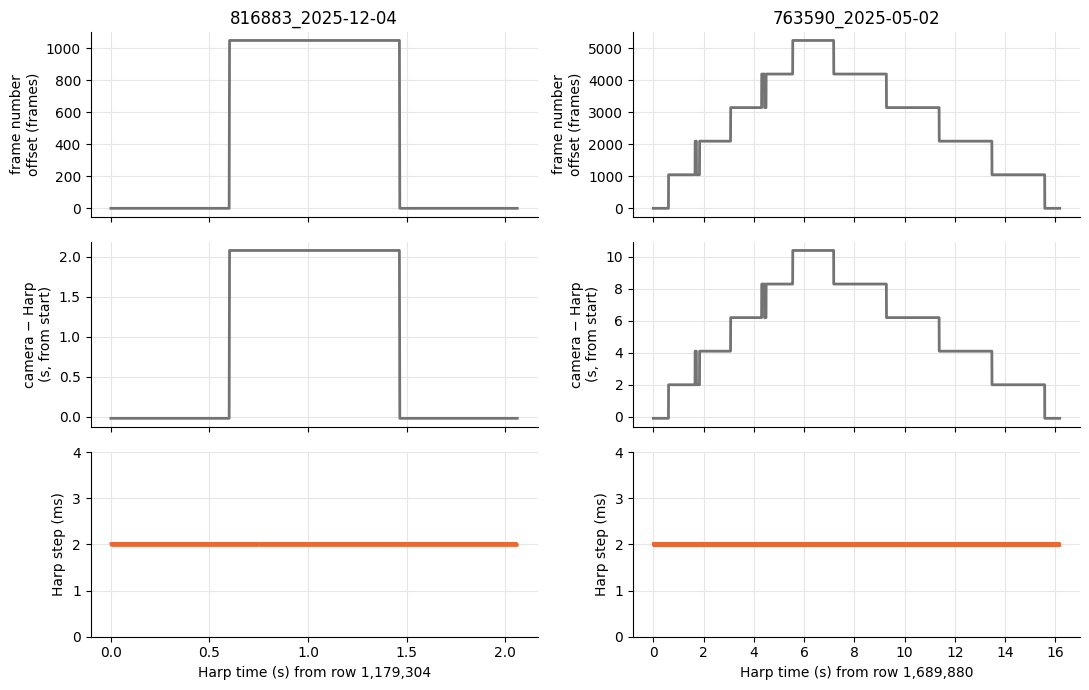

In [11]:
examples = {
    "816883_2025-12-04": timing,
    "763590_2025-05-02": load(
        "behavior_763590_2025-05-02_11-07-07", "BottomCamera/metadata.csv"
    )[0],
}
fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex="col")
for col, (name, t) in enumerate(examples.items()):
    f = t["frame_number"].to_numpy()
    c = t["camera_time"].to_numpy()
    h = t["harp_time_raw"].to_numpy()
    bad = np.flatnonzero(np.diff(f) != 1)
    rows = np.arange(bad[0] - 300, bad[-1] + 300)
    seconds = (h[rows] - h[rows[0]])
    frame_offset = f[rows] - f[0] - rows
    camera_offset = (c[rows] - c[0]) - (h[rows] - h[0])
    axes[0, col].plot(seconds, frame_offset, color=CAMERA)
    axes[0, col].set(title=name, ylabel="frame number\noffset (frames)")
    axes[1, col].plot(seconds, camera_offset, color=CAMERA)
    axes[1, col].set(ylabel="camera − Harp\n(s, from start)")
    axes[2, col].plot(seconds, np.diff(h)[rows - 1] * 1e3, color=AS_WRITTEN)
    axes[2, col].set(ylabel="Harp step (ms)", ylim=(0, 4),
                     xlabel=f"Harp time (s) from row {rows[0]:,}")
fig.tight_layout()

**Correction: none needed.** With no frames lost, row *n* was exposed by
trigger *n*, so the Harp column is right as written; frame numbers and
camera times are only needed to find lost frames, and are not used. The
verdict is `use` even though `frame_numbers_increase` and
`camera_time_increases` fail. (If frames had also been lost, the bad
metadata could not locate them and the camera would be excluded.)

In [12]:
fixed = vtq.correct_video_timing(timing, trigger_times=log)
print(fixed["harp_source"].value_counts().to_string())
difference = np.abs(timing["harp_time_raw"].to_numpy() - log[: len(timing)])
print(f"Harp column vs trigger log: max |difference| {difference.max() * 1e6:.1f} µs")

harp_source
trigger_log    2665141
Harp column vs trigger log: max |difference| 0.0 µs


## 5. Harp clock step

Twice per session, exactly 1,280 s apart and on a whole Harp second, the
Harp time steps **backward** on one row (−1.3 ms in `800886`, −0.5 ms in
`751181`) while the camera steps 2 ms as usual. The step undoes a ramp: for
~4–5 min before each step the Harp board's timestamps run 10–13 ppm faster
than in the rest of the session, against the camera, gaining 2.5–3.3 ms;
the step takes it back. Both are in the trigger log too (and the step in
the same board's 1 kHz analog stream), so it is the Harp Behavior board's
own clock that moves. The frames were still taken every 2 ms; only the
behavior clock's timestamps moved.

`harp_evenly_spaced` catches the step row. The ramp alone (10–13 ppm) is
within normal clock drift and would not be caught.

In [13]:
sessions = {
    "800886_2025-08-26": ("behavior_800886_2025-08-26_13-15-13", "bottom_camera.csv"),
    "751181_2025-02-26": ("behavior_751181_2025-02-26_11-51-15", "BottomCamera/metadata.csv"),
}
clock_steps = {}
for name, (session, csv) in sessions.items():
    print(name)
    timing, log = load(session, csv)
    checks = report(timing, log)
    steps = check_rows(checks, "harp_evenly_spaced")
    harp = timing["harp_time_raw"].to_numpy()
    print(f"steps {(harp[steps[1]] - harp[steps[0]]):.3f} s apart, at Harp times",
          harp[steps], "\n")
    clock_steps[name] = timing, log, steps

timing, log, steps = clock_steps["800886_2025-08-26"]
show(rows_table(
    timing, np.concatenate([np.arange(s - 2, s + 3) for s in steps]),
    **{"trigger log step (ms)": np.diff(log, prepend=np.nan) * 1e3},
))

800886_2025-08-26


✗ harp_evenly_spaced: steps off by > 0.5 frame: 2
verdict: exclude: harp_evenly_spaced
steps 1280.001 s apart, at Harp times [3975936.999456 3977217.000928] 

751181_2025-02-26


✗ harp_evenly_spaced: steps off by > 0.5 frame: 2
verdict: exclude: harp_evenly_spaced
steps 1279.999 s apart, at Harp times [5876481.00112  5877761.000064] 



,frame step,Harp (s),Harp step (ms),camera step (ms),trigger log step (ms)
row,,,,,
1581936,1,3163.835168,2.016,2.000,2.016
1581937,1,3163.837152,1.984,1.999,1.984
1581938,1,3163.835872,-1.280,2.003,-1.280
1581939,1,3163.837856,1.984,1.999,1.984
1581940,1,3163.839872,2.016,2.000,2.016
2221945,1,4443.836640,1.984,2.000,1.984
2221946,1,4443.838656,2.016,2.002,2.016
2221947,1,4443.837344,-1.312,2.000,-1.312
2221948,1,4443.839360,2.016,2.000,2.016


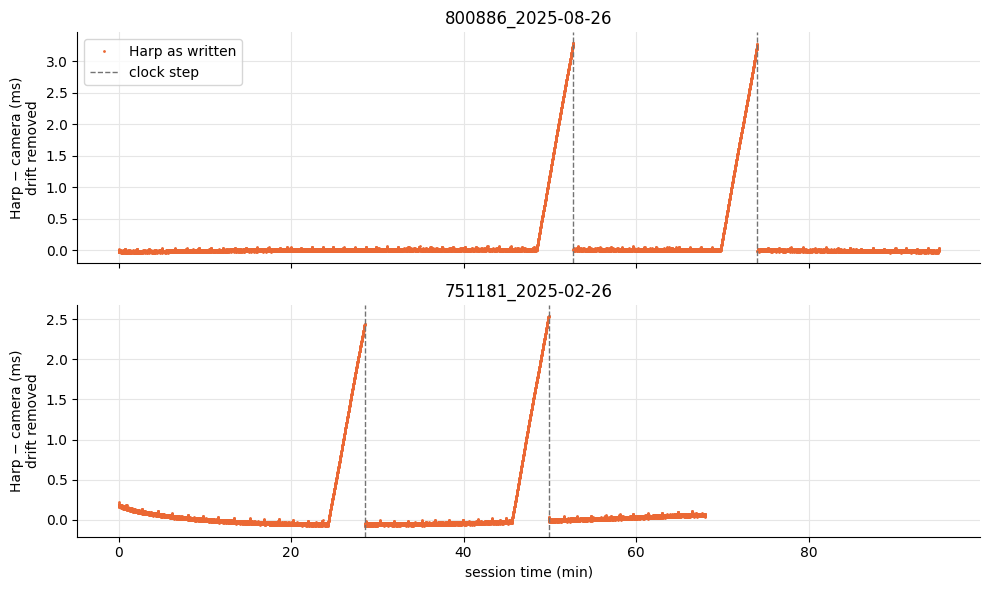

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, (name, (timing, log, steps)) in zip(axes, clock_steps.items()):
    # every 200th row: 0.4 s apart
    harp = timing["harp_time_raw"].to_numpy()[::200]
    camera = timing["camera_time"].to_numpy()[::200]
    minutes = (camera - camera[0]) / 60
    offset = harp - camera
    # remove the normal clock drift, fitted away from the ramps (6 min
    # before each step)
    steady = np.all([
        (minutes < minutes[s // 200] - 6) | (minutes >= minutes[s // 200])
        for s in steps
    ], axis=0)
    slope, intercept = np.polyfit(minutes[steady], offset[steady], 1)
    residual = (offset - intercept - slope * minutes) * 1e3
    ax.plot(minutes, residual, ".", color=AS_WRITTEN, markersize=2,
            label="Harp as written")
    for s in steps:
        ax.axvline(minutes[s // 200], color=CAMERA, linestyle="--", linewidth=1)
    ax.set(title=name, ylabel="Harp − camera (ms)\ndrift removed")
    if ax is axes[0]:
        ax.plot([], [], "--", color=CAMERA, linewidth=1, label="clock step")
        ax.legend(loc="upper left")
axes[-1].set(xlabel="session time (min)")
fig.tight_layout()

**Not corrected: excluded** (`harp_evenly_spaced`). It is the behavior
clock itself that moved, so there is no single right answer for the video
times: matching the camera would disagree with the behavior events logged
on the stepped clock, and a value in between would be neither. In 14 of
the 56 cameras in the screen, frames were also lost; the step is caught the
same way, since the Harp column stays evenly spaced through drops.

## 6. More triggers than exposures

The trigger log has more events than the frame numbers span (normally
equal): 1,326 extra in `818586_2026-01-16` (no frames lost), 1 or 2 extra
in the other cameras (all with heavy frame loss). The data cannot say where
the extra triggers are:

- **at the end** (triggers after recording stopped): the Harp column is right;
- **at the start** (exposures before the first saved frame): every row is
  early by the extra triggers × 2 ms.

The CSV matching the log's first *N* events does not help: the pairing
makes that true either way.

In [15]:
summary = {}
for name, session in [
    ("818586_2026-01-16", "behavior_818586_2026-01-16_09-19-39"),
    ("818580_2025-11-25", "behavior_818580_2025-11-25_10-33-49"),
]:
    print(name)
    timing, log = load(session)
    report(timing, log)
    print()
    frames = timing["frame_number"].to_numpy()
    exposures = frames[-1] - frames[0] + 1
    summary[name] = {
        "rows": len(timing),
        "exposures": exposures,
        "frames lost": exposures - len(timing),
        "log events": len(log),
        "extra events": len(log) - exposures,
        "error if extras at start (s)": (len(log) - exposures)
        * vtq.frame_interval(log),
    }
pd.DataFrame(summary).style.format(
    lambda v: f"{v:,.0f}" if float(v).is_integer() else f"{v:,.3f}"
)

818586_2026-01-16


✗ trigger_log_count: trigger log has 2623676 events, frame numbers span 2622350 exposures
verdict: exclude: trigger_log_count

818580_2025-11-25


✗ no_frames_lost: frames lost: 168143
✗ trigger_log_count: trigger log has 2636467 events, frame numbers span 2636466 exposures
verdict: exclude: trigger_log_count



,818586_2026-01-16,818580_2025-11-25
rows,"2,622,350","2,468,323"
exposures,"2,622,350","2,636,466"
frames lost,0,"168,143"
log events,"2,623,676","2,636,467"
extra events,"1,326",1
error if extras at start (s),2.652,0.002


**Not corrected: excluded** (`trigger_log_count`). Whether extras at the end
can be shown and accepted is open (`VIDEO_SCREEN_PLAN.md`).

## 7. Camera not following the trigger

In `816212_2025-12-24` the bottom camera exposed every 6.635 ms (~150.7
fps) instead of on each 2 ms trigger, while the side camera, on the same
triggers, exposed every 2 ms. 6.635 ms is not a multiple of 2 ms, so the
camera seems to have run freely rather than on the trigger. The Harp column
still pairs row *n* with trigger *n*, 2 ms apart, so it covers only the
first ~20 min of an 88 min recording.

In [16]:
session = "behavior_816212_2025-12-24_10-59-57"
cameras = {}
for csv in ["bottom_camera.csv", "side_camera_right.csv"]:
    print(csv)
    timing, log = load(session, csv)
    report(timing, log)
    print()
    cameras[csv.split("_camera")[0]] = timing

rows = {}
for name, timing in cameras.items():
    frames = timing["frame_number"].to_numpy()
    camera = timing["camera_time"].to_numpy()
    harp = timing["harp_time_raw"].to_numpy()
    exposures = frames[-1] - frames[0] + 1
    rows[name] = {
        "rows": len(timing),
        "exposures (log: triggers)": exposures,
        "camera: recording (min)": (camera[-1] - camera[0]) / 60,
        "camera: interval per exposure (ms)": (camera[-1] - camera[0]) / (exposures - 1) * 1e3,
        "Harp column: span (min)": (harp[-1] - harp[0]) / 60,
        "Harp column: interval per row (ms)": (harp[-1] - harp[0]) / (len(harp) - 1) * 1e3,
    }
rows["trigger log"] = {
    "exposures (log: triggers)": len(log),
    "Harp column: span (min)": (log[-1] - log[0]) / 60,
    "Harp column: interval per row (ms)": (log[-1] - log[0]) / (len(log) - 1) * 1e3,
}
pd.DataFrame(rows).style.format(
    lambda v: "" if pd.isna(v) else f"{v:,.0f}" if float(v).is_integer() else f"{v:,.3f}"
)

bottom_camera.csv


✗ no_frames_lost: frames lost: 198678
✗ clock_rates_agree: Harp runs -698583.3 ppm against camera (limit 100)
✗ trigger_log_count: trigger log has 2638321 events, frame numbers span 795227 exposures
verdict: exclude: clock_rates_agree

side_camera_right.csv


verdict: use



,bottom,side,trigger log
rows,"596,549","2,638,321",
exposures (log: triggers),"795,227","2,638,321","2,638,321"
camera: recording (min),87.942,87.942,
camera: interval per exposure (ms),6.635,2.000,
Harp column: span (min),19.885,87.943,87.943
Harp column: interval per row (ms),2.000,2.000,2.000


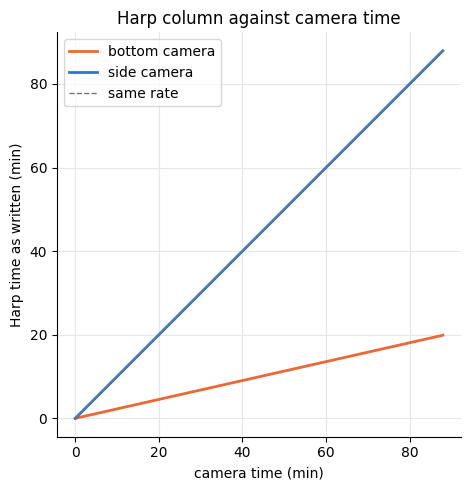

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for (name, timing), colour in zip(cameras.items(), [AS_WRITTEN, CORRECTED]):
    camera = timing["camera_time"].to_numpy()[::500]
    harp = timing["harp_time_raw"].to_numpy()[::500]
    ax.plot((camera - camera[0]) / 60, (harp - harp[0]) / 60, color=colour,
            label=f"{name} camera")
end = (log[-1] - log[0]) / 60
ax.plot([0, end], [0, end], "--", color=CAMERA, linewidth=1, label="same rate")
ax.set(xlabel="camera time (min)", ylabel="Harp time as written (min)",
       title="Harp column against camera time", aspect="equal")
ax.legend()
fig.tight_layout()

**Not corrected: excluded** (`clock_rates_agree`: Harp advances 2.0 ms per
row, the camera 6.6 ms per exposure). Re-indexing assumes exposure *k* was
taken by trigger *k*; here no exposure can be matched to a trigger. The
trigger log count fails too (2.64 M events for 795 k exposures), and the
camera also lost 198,678 frames on top.